In [3]:
import sys
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.ar_model import AutoReg
from data_loader import PairData

pairs = [
    ("MPC",  "PSX"),
    ("PEP",  "KO"),
    ("AAPL", "MSFT"),
    ("JPM",  "BAC"),
    ("XOM",  "CVX"),
    ("MCD",  "YUM"),
    ("GS",   "MS"),
    ("V",    "MA"),
    ("HD",   "LOW"),
    ("T",    "VZ"),
]

def hurst_exponent(ts, max_lag=100):
    """Variance-ratio Hurst exponent. H<0.5 mean-reverting, H=0.5 random walk, H>0.5 trending."""
    lags = range(2, min(max_lag, len(ts) // 2))
    tau = [np.std(ts[lag:] - ts[:-lag]) for lag in lags]
    return np.polyfit(np.log(list(lags)), np.log(tau), 1)[0]

def half_life(spread):
    """OU half-life in days from AR(1) fit."""
    res = AutoReg(spread, lags=1).fit()
    phi = res.params[1]
    return -np.log(2) / np.log(np.clip(phi, 1e-9, 1 - 1e-9))

def run_tests(t1, t2):
    data  = PairData(f"../../data/real_pair_{t1}_{t2}.csv")
    s0, s1 = np.log(data.s[0]), np.log(data.s[1])

    # Johansen beta on full series
    jres  = coint_johansen(np.column_stack([s0, s1]), det_order=0, k_ar_diff=1)
    cv    = jres.evec[:, 0]
    beta  = -cv[1] / cv[0]
    spread = s0 - beta * s1
    spread -= spread.mean()

    # ADF on spread
    adf_res = adfuller(spread, autolag='AIC')
    adf_p, adf_cv5 = adf_res[1], adf_res[4]['5%']

    # Engle-Granger cointegration test
    _, eg_p, _ = coint(s0, s1)

    # Johansen trace statistic (H0: r=0) vs 95% critical value
    trace_stat  = jres.lr1[0]
    trace_cv95  = jres.cvt[0, 1]

    # Half-life and Hurst
    hl = half_life(spread)
    H  = hurst_exponent(spread)

    # Log-return correlation
    corr = np.corrcoef(np.diff(s0), np.diff(s1))[0, 1]

    return {
        "Pair":              f"{t1}/{t2}",
        "ADF p-val":         round(adf_p, 4),
        "ADF pass (5%)": "✓" if adf_p < 0.05 else "✗",
        "EG p-val":          round(eg_p, 4),
        "EG pass (5%)":  "✓" if eg_p  < 0.05 else "✗",
        "Johansen trace":    round(trace_stat, 2),
        "Johansen CV 95%":   round(trace_cv95,  2),
        "Johansen pass": "✓" if trace_stat > trace_cv95 else "✗",
        "Half-life (days)":  round(hl, 1),
        "Hurst exp":         round(H,  3),
        "Return corr":       round(corr, 3),
    }

rows = [run_tests(t1, t2) for t1, t2 in pairs]
df = pd.DataFrame(rows).set_index("Pair")
df

,ADF p-val,ADF pass (5%),EG p-val,EG pass (5%),Johansen trace,Johansen CV 95%,Johansen pass,Half-life (days),Hurst exp,Return corr
Pair,,,,,,,,,,
MPC/PSX,0.0084,✓,0.0994,✗,13.13,15.49,✗,112.8,0.433,0.794
PEP/KO,0.2839,✗,0.5248,✗,5.40,15.49,✗,302.7,0.460,0.694
AAPL/MSFT,0.0543,✗,0.1952,✗,7.48,15.49,✗,401.7,0.494,0.544
JPM/BAC,0.0525,✗,0.3723,✗,8.01,15.49,✗,432.2,0.523,0.827
XOM/CVX,0.3732,✗,0.8868,✗,5.37,15.49,✗,666.1,0.400,0.856
MCD/YUM,0.0006,✓,0.0031,✓,25.89,15.49,✓,81.8,0.448,0.603
GS/MS,0.0410,✓,0.1477,✗,12.36,15.49,✗,164.8,0.382,0.827
V/MA,0.0262,✓,0.0879,✗,22.20,15.49,✓,62.2,0.372,0.832
HD/LOW,0.1423,✗,0.3129,✗,14.52,15.49,✗,256.7,0.433,0.819


In [4]:
# Styled table: colour p-values and pass/fail cells
def color_pval(val):
    if isinstance(val, float):
        if val < 0.01:  return "background-color: #c6efce; color: #276221"
        if val < 0.05:  return "background-color: #ffeb9c; color: #9c5700"
        return             "background-color: #ffc7ce; color: #9c0006"
    return ""

def color_pass(val):
    if val == "✓": return "background-color: #c6efce; color: #276221; font-weight: bold"
    if val == "✗": return "background-color: #ffc7ce; color: #9c0006; font-weight: bold"
    return ""

def color_hurst(val):
    if isinstance(val, float):
        if val < 0.4:  return "background-color: #c6efce; color: #276221"
        if val < 0.5:  return "background-color: #ffeb9c; color: #9c5700"
        return            "background-color: #ffc7ce; color: #9c0006"
    return ""

styled = (df.style
    .map(color_pval,  subset=["ADF p-val", "EG p-val"])
    .map(color_pass,  subset=["ADF pass (5%)", "EG pass (5%)", "Johansen pass"])
    .map(color_hurst, subset=["Hurst exp"])
    .format({
        "ADF p-val": "{:.4f}",
        "EG p-val":  "{:.4f}",
        "Half-life (days)": "{:.1f}",
        "Hurst exp": "{:.3f}",
        "Return corr": "{:.3f}",
    })
    .set_caption("Pairs cointegration statistics (full dataset, log prices)")
)
styled

,ADF p-val,ADF pass (5%),EG p-val,EG pass (5%),Johansen trace,Johansen CV 95%,Johansen pass,Half-life (days),Hurst exp,Return corr
Pair,,,,,,,,,,
MPC/PSX,0.0084,✓,0.0994,✗,13.130000,15.490000,✗,112.8,0.433,0.794
PEP/KO,0.2839,✗,0.5248,✗,5.400000,15.490000,✗,302.7,0.460,0.694
AAPL/MSFT,0.0543,✗,0.1952,✗,7.480000,15.490000,✗,401.7,0.494,0.544
JPM/BAC,0.0525,✗,0.3723,✗,8.010000,15.490000,✗,432.2,0.523,0.827
XOM/CVX,0.3732,✗,0.8868,✗,5.370000,15.490000,✗,666.1,0.400,0.856
MCD/YUM,0.0006,✓,0.0031,✓,25.890000,15.490000,✓,81.8,0.448,0.603
GS/MS,0.0410,✓,0.1477,✗,12.360000,15.490000,✗,164.8,0.382,0.827
V/MA,0.0262,✓,0.0879,✗,22.200000,15.490000,✓,62.2,0.372,0.832
HD/LOW,0.1423,✗,0.3129,✗,14.520000,15.490000,✗,256.7,0.433,0.819


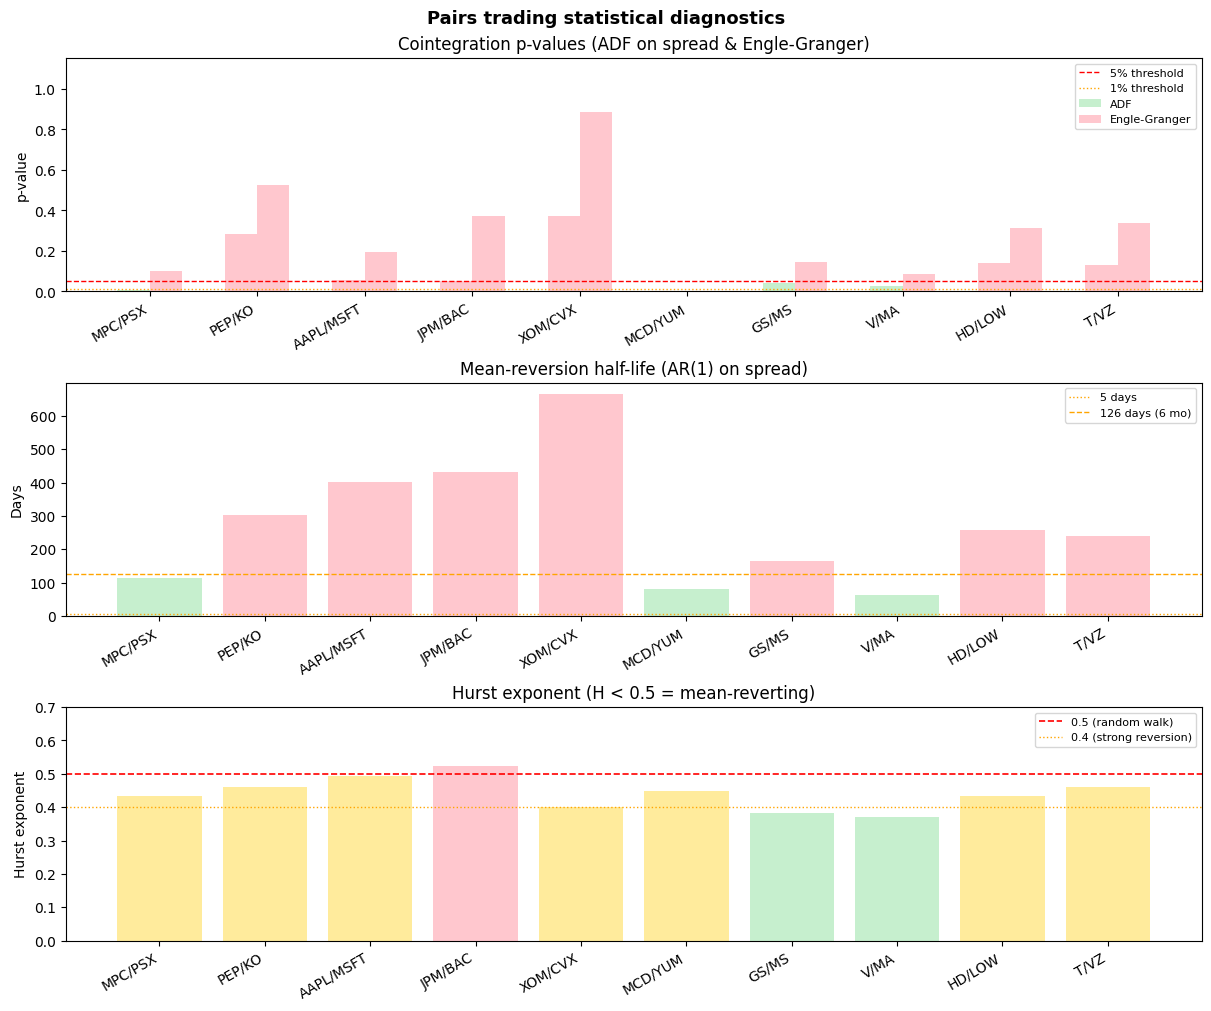

In [5]:
pair_labels = df.index.tolist()
x = np.arange(len(pair_labels))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)
fig.suptitle("Pairs trading statistical diagnostics", fontsize=13, fontweight="bold")

# --- p-values ---
ax = axes[0]
w = 0.3
bars_adf = ax.bar(x - w/2, df["ADF p-val"], width=w, label="ADF",            color=["#c6efce" if v < 0.05 else "#ffc7ce" for v in df["ADF p-val"]])
bars_eg  = ax.bar(x + w/2, df["EG p-val"],  width=w, label="Engle-Granger",  color=["#c6efce" if v < 0.05 else "#ffc7ce" for v in df["EG p-val"]])
ax.axhline(0.05, color="red",    linewidth=1, linestyle="--", label="5% threshold")
ax.axhline(0.01, color="orange", linewidth=1, linestyle=":",  label="1% threshold")
ax.set_xticks(x); ax.set_xticklabels(pair_labels, rotation=30, ha="right")
ax.set_ylabel("p-value"); ax.set_title("Cointegration p-values (ADF on spread & Engle-Granger)")
ax.legend(fontsize=8); ax.set_ylim(0, max(df[["ADF p-val","EG p-val"]].max()) * 1.3)

# --- Half-life ---
ax = axes[1]
colors = ["#c6efce" if 5 < v < 126 else "#ffeb9c" if v <= 5 else "#ffc7ce" for v in df["Half-life (days)"]]
ax.bar(x, df["Half-life (days)"], color=colors)
ax.axhline(5,   color="orange", linewidth=1, linestyle=":",  label="5 days")
ax.axhline(126, color="orange", linewidth=1, linestyle="--", label="126 days (6 mo)")
ax.set_xticks(x); ax.set_xticklabels(pair_labels, rotation=30, ha="right")
ax.set_ylabel("Days"); ax.set_title("Mean-reversion half-life (AR(1) on spread)")
ax.legend(fontsize=8)

# --- Hurst exponent ---
ax = axes[2]
colors = ["#c6efce" if v < 0.4 else "#ffeb9c" if v < 0.5 else "#ffc7ce" for v in df["Hurst exp"]]
ax.bar(x, df["Hurst exp"], color=colors)
ax.axhline(0.5, color="red",    linewidth=1.2, linestyle="--", label="0.5 (random walk)")
ax.axhline(0.4, color="orange", linewidth=1,   linestyle=":",  label="0.4 (strong reversion)")
ax.set_xticks(x); ax.set_xticklabels(pair_labels, rotation=30, ha="right")
ax.set_ylabel("Hurst exponent"); ax.set_title("Hurst exponent (H < 0.5 = mean-reverting)")
ax.set_ylim(0, 0.7); ax.legend(fontsize=8)

plt.savefig("../../paper/pair_statistics.pdf", bbox_inches="tight")
plt.show()